In [12]:
import json

import gc_utils
import gizmo_analysis as gizmo
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
from matplotlib import colors

In [13]:
sim = "m12m"
# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

In [14]:
fire_dir = sim_dir + sim + "/" + sim + "_res7100/"
# halt = gc_utils.get_halo_tree(sim, sim_dir, species="star")
part = gc_utils.open_snapshot(600, fire_dir, species=["star", "gas"])

Retrieving Snapshot 600..................: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [03:00<00:00, 180.90s/it]


Text(0.5, 0, 'x (kpc)')

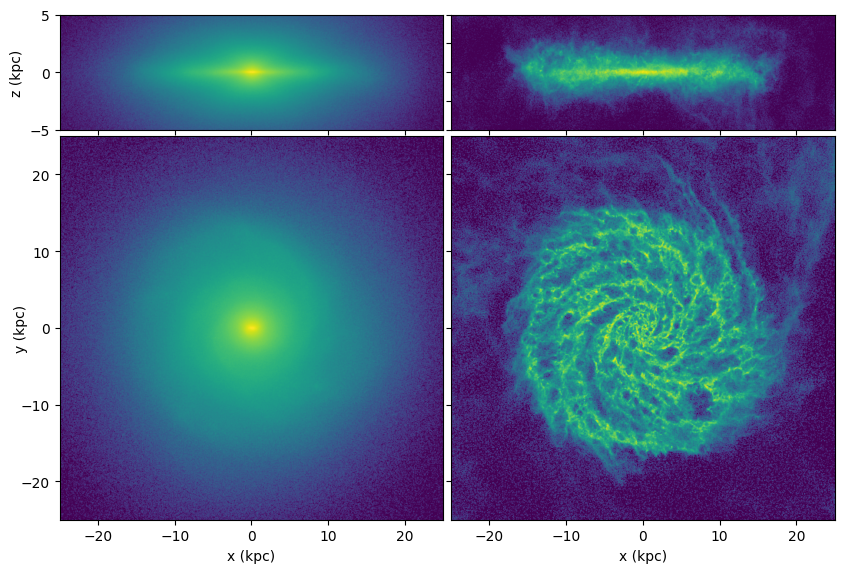

In [17]:
r_lim = 25
distance_bin_width = 0.1
position_bin_number = int(np.round(2 * np.max(r_lim) / distance_bin_width))

sta_dis = part["star"].prop("host.distance.principal.total")
sta_dis_msk = sta_dis <= 2 * r_lim
sta_pos = part["star"].prop("host.distance.principal")[sta_dis_msk]
sta_mas = part["star"]["mass"][sta_dis_msk]

gas_dis = part["gas"].prop("host.distance.principal.total")
gas_dis_msk = gas_dis <= 2 * r_lim
gas_pos = part["gas"].prop("host.distance.principal")[gas_dis_msk]
gas_mas = part["gas"]["mass"][gas_dis_msk]

# Adjustable ratio of bottom row height vs top row height
height_ratio = 2

fig = plt.figure(figsize=(10, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1, height_ratio])
color_map = plt.cm.viridis


axs = [
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
]


def compute_and_plot_hist(x, y, mass, bins, limits, ax):
    hist, x_edges, y_edges = np.histogram2d(x, y, bins=bins, range=limits, weights=mass)
    hist /= np.diff(x_edges)[0] * np.diff(y_edges)[0]
    hist = np.nan_to_num(hist, nan=0)
    min_pos = hist[hist > 0].min()
    hist[hist == 0] = min_pos
    im = ax.imshow(
        hist.T,
        norm=colors.LogNorm(),
        cmap=color_map,
        aspect="auto",
        interpolation="bilinear",
        extent=np.concatenate(limits),
    )
    return im


# star x, y (bottom left)
position_limits = np.array([[-r_lim, r_lim], [-r_lim, r_lim]])
compute_and_plot_hist(sta_pos[:, 0], sta_pos[:, 1], sta_mas, position_bin_number, position_limits, axs[1][0])

# star x, z (top left)
position_limits = np.array([[-r_lim, r_lim], [-5, 5]])
compute_and_plot_hist(sta_pos[:, 0], sta_pos[:, 2], sta_mas, position_bin_number, position_limits, axs[0][0])

# gas x, y (bottom right)
position_limits = np.array([[-r_lim, r_lim], [-r_lim, r_lim]])
compute_and_plot_hist(gas_pos[:, 0], gas_pos[:, 1], gas_mas, position_bin_number, position_limits, axs[1][1])

# gas x, z (top right)
position_limits = np.array([[-r_lim, r_lim], [-5, 5]])
compute_and_plot_hist(gas_pos[:, 0], gas_pos[:, 2], gas_mas, position_bin_number, position_limits, axs[0][1])

# Set aspect ratios
axs[0][0].set_aspect(1.5)  # top left rectangular
axs[0][1].set_aspect(1.5)  # top right rectangular

axs[1][0].set_aspect(1)  # bottom left square
axs[1][1].set_aspect(1)  # bottom right square

axs[0][0].set_xticklabels([])
axs[0][1].set_xticklabels([])

axs[0][1].set_yticklabels([])
axs[1][1].set_yticklabels([])

# Adjust spacing
plt.subplots_adjust(hspace=-0.415, wspace=0.02)

axs[0][0].set_xticks([-20, -10, 0, 10, 20])
axs[0][1].set_xticks([-20, -10, 0, 10, 20])
axs[1][0].set_xticks([-20, -10, 0, 10, 20])
axs[1][1].set_xticks([-20, -10, 0, 10, 20])

axs[0][0].set_yticks([-5, 0, 5])
axs[1][0].set_yticks([-20, -10, 0, 10, 20])
axs[1][1].set_yticks([-20, -10, 0, 10, 20])

axs[0][0].set_ylabel("z (kpc)")

axs[1][0].set_xlabel("x (kpc)")
axs[1][0].set_ylabel("y (kpc)", labelpad=-5)

axs[1][1].set_xlabel("x (kpc)")